# Exploring Priority BFS 

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import datetime

In [46]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [47]:
colnames = ["time_interval", "id_1", "id_2", "class_id_1", "class_id_2"]

df_2012 = pd.read_csv(
    "thiers_2012.csv",
    sep="\t",
    header=None,
    names=colnames
)

# Convert to datetime (UTC)
df_2012["datetime_utc"] = pd.to_datetime(df_2012["time_interval"], unit="s", utc=True)

print("2012 interactions:")
display(df_2012.head())

2012 interactions:


,time_interval,id_1,id_2,class_id_1,class_id_2,datetime_utc
0,1353303380,1170,1644,MP*1,MP*1,2012-11-19 05:36:20+00:00
1,1353303400,1170,1613,MP*1,MP*1,2012-11-19 05:36:40+00:00
2,1353303640,1170,1644,MP*1,MP*1,2012-11-19 05:40:40+00:00
3,1353303760,1181,1651,MP*1,MP*1,2012-11-19 05:42:40+00:00
4,1353303840,1108,1190,MP*1,MP*1,2012-11-19 05:44:00+00:00


# Testing NetworkRugs on our new data

> **Events → Windows → Graphs → Ordering → NetworkRug → Interpretation**

### Phase A: Turn data data into snapshots (most important step)+ choose a time granularity
Rule of thumb: too fine → noise, too coarse → nothing happens


### Defining the window

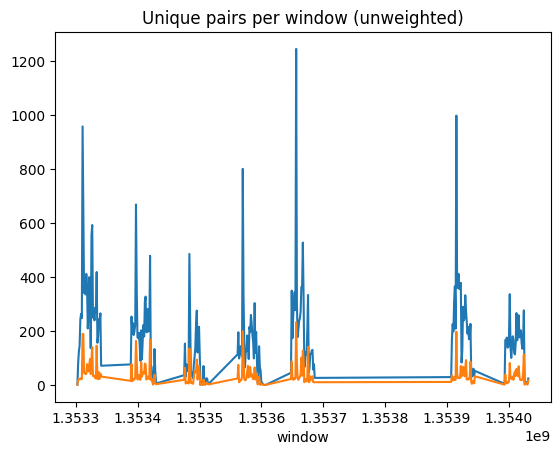

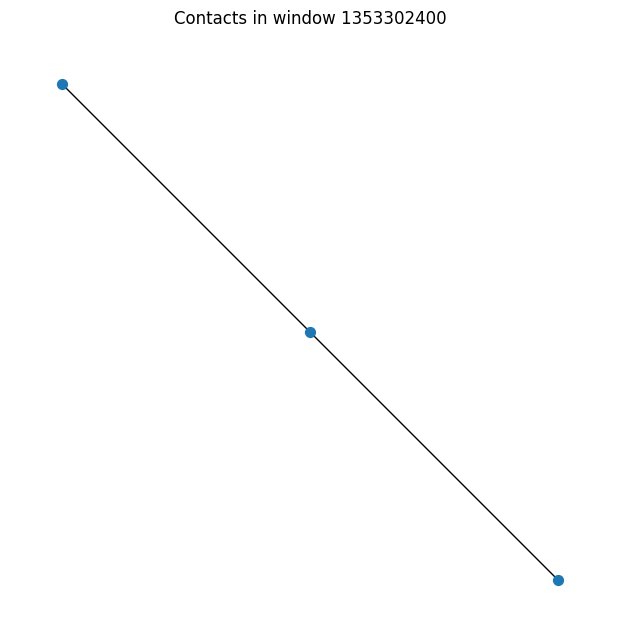

In [48]:
# Creating window column
window = 1200 # 300  # 5 minutes in seconds
df_2012["window"] = (df_2012["time_interval"] // window) * window

# Interactions per window overview
interactions_per_window = (
    df_2012
    .groupby("window")
    .size()
)

interactions_per_window.plot()

# Unique pairs per window shown for reference - graphs are built with weights below
df_2012["u"] = df_2012[["id_1", "id_2"]].min(axis=1)
df_2012["v"] = df_2012[["id_1", "id_2"]].max(axis=1)

# without weights
unique_pairs_per_window = (
    df_2012
    .drop_duplicates(subset=["window", "u", "v"])
    .groupby("window")
    .size()
)
unique_pairs_per_window.plot(title="Unique pairs per window (unweighted)")

# Visualizing a single window network (weighted)
one_window = df_2012["window"].iloc[0]
df_w = df_2012[df_2012["window"] == one_window]

edge_weights = df_w.groupby(["u", "v"]).size().reset_index(name="weight")
G = nx.from_pandas_edgelist(edge_weights, "u", "v", edge_attr="weight")

plt.figure(figsize=(6, 6))
nx.draw(G, node_size=50, with_labels=False)
plt.title(f"Contacts in window {one_window}")
plt.show()





### Phase B: Build snapshot graphs

In [49]:
# ensuring global node setting (reference roster of students)
nodes = pd.unique(df_2012[["id_1", "id_2"]].values.ravel())
print(f"Total unique students: {len(nodes)}")


Total unique students: 180


## Important question: Do we want to visualize the empty (non-interaction) windows?
### If no, we remove them from our data:

In [50]:
graphs = {}
for w, df_w in df_2012.groupby("window"):
    G = nx.Graph()
    G.add_nodes_from(nodes)
    
    # Count interactions as edge weight
    edge_weights = (
        df_w.groupby(["u", "v"])
        .size()
        .reset_index(name="weight")
    )
    G.add_weighted_edges_from(
        edge_weights[["u", "v", "weight"]].itertuples(index=False)
    )
    graphs[w] = G

In [51]:
sample_graph = graphs[list(graphs.keys())[4]]
sample_edges = list(sample_graph.edges(data=True))[:5]
print(sample_edges)
# Should show: [(u, v, {'weight': N}), ...]
# If weight is missing, calculate_priority won't work correctly

[(1170, 1672, {'weight': 3}), (1613, 1108, {'weight': 1}), (1613, 1632, {'weight': 1}), (1613, 1672, {'weight': 4}), (1651, 1674, {'weight': 1})]


In [52]:
# Current - start_node is ignored!

from ba_utils.orderings import get_priority_bfs_ordering, get_start_node
from ba_utils.network_rugs import draw_rug_from_graphs

prio_bfs_ordering = get_priority_bfs_ordering(graphs)

print("Priority BFS Ordering:")
draw_rug_from_graphs(
    graphs_data=graphs,
    ordering=prio_bfs_ordering,
    color_encoding="degree",
    pixel_size=6
)

Global stats: ((1, 60), (0, 17), (0, 7))
Priority BFS Ordering:
num_artists 1


Global stats: ((1, 60), (0, 17), (0, 7))
Priority BFS Ordering:
num_artists 3


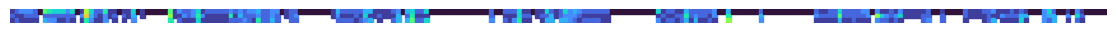

In [55]:
# option 2 - Defining a specific start_node - Frederike's Priority BFS
start_nodes = get_start_node(graphs, metric='degree', mode='highest_global')
prio_bfs_ordering = get_priority_bfs_ordering(graphs, start_nodes=start_nodes)

print("Priority BFS Ordering:")
draw_rug_from_graphs(
    graphs_data=graphs,
    ordering=prio_bfs_ordering,
    color_encoding="degree",
    pixel_size=6
)

Priority BFS Ordering:
num_artists 180


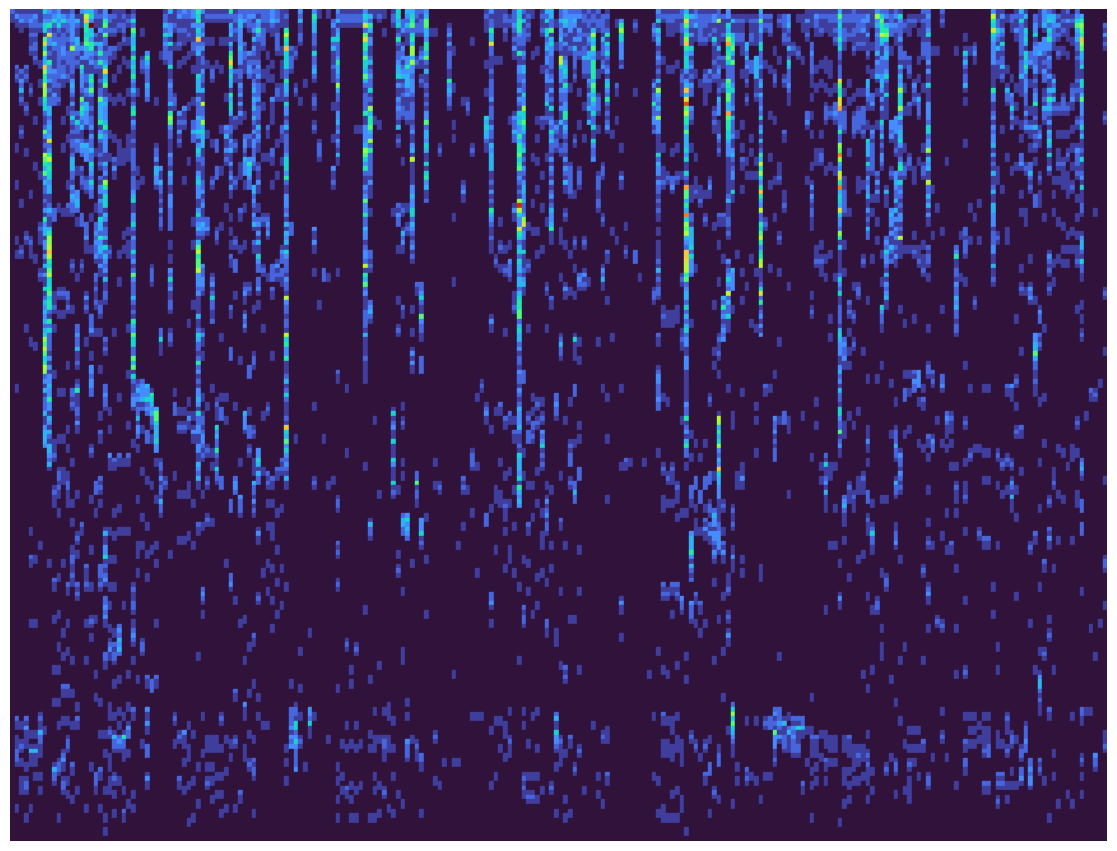

In [56]:
# option 3 - Fixed start_node - adapted priority bfs
from ba_utils.orderings import get_priority_bfs_ordering_2, get_start_node
from ba_utils.network_rugs import draw_rug_from_graphs


"""    Select a single consistent start node, either:
      - 'highest' / 'lowest':   extreme on the first graph
      - 'highest_global' / 'lowest_global': extreme aggregated across all graphs
"""


start_nodes = get_start_node(graphs, metric='degree', mode='highest')
prio_bfs_ordering_2 = get_priority_bfs_ordering_2(graphs, start_nodes=start_nodes)

print("Priority BFS Ordering:")
draw_rug_from_graphs(
    graphs_data=graphs,
    ordering=prio_bfs_ordering_2,
    color_encoding="degree",
    pixel_size=6
)

In [57]:
sample = graphs[list(graphs.keys())[0]]
components = list(nx.connected_components(sample))
print(f"Number of components: {len(components)}")
print(f"Total nodes: {sample.number_of_nodes()}")
print(f"Nodes with edges: {sum(1 for n in sample.nodes if sample.degree(n) > 0)}")
print(f"Isolated nodes: {len(list(nx.isolates(sample)))}")

Number of components: 178
Total nodes: 180
Nodes with edges: 3
Isolated nodes: 177


## Using a rolling windows approach to avoid the stopping of the algorithm once all nodes in x window have been reached

In [58]:
# 1. LOAD DATA
colnames = ["time_interval", "id_1", "id_2", "class_id_1", "class_id_2"]

df_2012 = pd.read_csv(
    "thiers_2012.csv",
    sep="\t",
    header=None,
    names=colnames
)

# Convert to datetime (UTC)
df_2012["datetime_utc"] = pd.to_datetime(df_2012["time_interval"], unit="s", utc=True)


# 2. CREATE WINDOW COLUMN
window = 1200
df_2012["window"] = (df_2012["time_interval"] // window) * window

# 3. CREATE u/v COLUMNS
df_2012["u"] = df_2012[["id_1", "id_2"]].min(axis=1)
df_2012["v"] = df_2012[["id_1", "id_2"]].max(axis=1)

# 4. DEFINE GLOBAL NODES
nodes = pd.unique(df_2012[["id_1", "id_2"]].values.ravel())

# 5. BUILD GRAPHS WITH ROLLING WINDOW ← replaces your old graph building loop
all_windows = sorted(df_2012["window"].unique())
lookback = 4

graphs = {}
for i, w in enumerate(all_windows):
    G = nx.Graph()
    G.add_nodes_from(nodes)
    
    past_windows = all_windows[max(0, i-lookback):i+1]
    df_past = df_2012[df_2012["window"].isin(past_windows)]
    
    edge_weights = (
        df_past.groupby(["u", "v"])
        .size()
        .reset_index(name="weight")
    )
    G.add_weighted_edges_from(
        edge_weights[["u", "v", "weight"]].itertuples(index=False)
    )
    graphs[w] = G

# 6. SANITY CHECK
sample = graphs[list(graphs.keys())[4]]  # use index 4 so lookback is fully active
print(f"Components: {len(list(nx.connected_components(sample)))}")
print(f"Isolated nodes: {len(list(nx.isolates(sample)))}")
print(f"Nodes with edges: {sum(1 for n in sample.nodes if sample.degree(n) > 0)}")

# 7. RUN PRIORITY BFS
#start_nodes = get_start_node(graphs, metric='degree', mode='lowest_global')
#prio_bfs_ordering = get_priority_bfs_ordering_2(graphs, start_nodes=start_nodes)

Components: 138
Isolated nodes: 126
Nodes with edges: 54


In [59]:
for lookback in [4, 8, 12, 24]:
    graphs_test = {}
    all_windows = sorted(df_2012["window"].unique())
    
    for i, w in enumerate(all_windows):
        G = nx.Graph()
        G.add_nodes_from(nodes)
        past_windows = all_windows[max(0, i-lookback):i+1]
        df_past = df_2012[df_2012["window"].isin(past_windows)]
        edge_weights = df_past.groupby(["u", "v"]).size().reset_index(name="weight")
        G.add_weighted_edges_from(edge_weights[["u", "v", "weight"]].itertuples(index=False))
        graphs_test[w] = G
    
    # Check a middle window where lookback is fully active
    mid = list(graphs_test.keys())[len(graphs_test)//2]
    sample = graphs_test[mid]
    isolated = len(list(nx.isolates(sample)))
    print(f"lookback={lookback}: isolated={isolated}, nodes with edges={sample.number_of_nodes()-isolated}")

lookback=4: isolated=69, nodes with edges=111
lookback=8: isolated=57, nodes with edges=123
lookback=12: isolated=41, nodes with edges=139
lookback=24: isolated=34, nodes with edges=146


### Are all students from the same class active at the same time?

In [60]:
print(df_2012.groupby(["window", "class_id_1"]).size().unstack().head(10))

class_id_1   MP*1  MP*2     PC   PC*   PSI*
window                                     
1353302400    2.0   NaN    NaN   NaN    NaN
1353303600   31.0   NaN   48.0   1.0    NaN
1353304800   28.0   NaN   97.0   NaN    NaN
1353306000   56.0   NaN   91.0   NaN    NaN
1353307200  130.0   NaN   98.0   NaN   16.0
1353308400  126.0   NaN  100.0   NaN   38.0
1353309600  106.0   NaN  116.0   NaN   26.0
1353310800  411.0   NaN  332.0  55.0  160.0
1353312000  187.0   NaN  249.0  98.0  136.0
1353313200  136.0   NaN   87.0  35.0   83.0


In [61]:
interactions_per_window = df_2012.groupby("window").size()

print(interactions_per_window.describe())
print(f"\nFirst 10 windows:\n{interactions_per_window.head(10)}")
print(f"\nWindows with > 50 interactions: {(interactions_per_window > 50).sum()}")

count     236.000000
mean      190.877119
std       167.351528
min         1.000000
25%        75.750000
50%       169.500000
75%       257.500000
max      1245.000000
dtype: float64

First 10 windows:
window
1353302400      2
1353303600     80
1353304800    125
1353306000    147
1353307200    244
1353308400    264
1353309600    248
1353310800    958
1353312000    670
1353313200    341
dtype: int64

Windows with > 50 interactions: 193


In [62]:
# Only keep windows with meaningful activity
active_windows = interactions_per_window[interactions_per_window > 50].index
df_active = df_2012[df_2012["window"].isin(active_windows)]

print(f"Windows before filter: {len(interactions_per_window)}")
print(f"Windows after filter: {len(active_windows)}")

Windows before filter: 236
Windows after filter: 193


Using **altered Priority BFS** (ensures all nodes are traversed), but might look exactly like bfs visualizaition...

Windows before filter: 236
Windows after filter: 193
Components: 64
Isolated nodes: 59
Nodes with edges: 121
num_artists 180


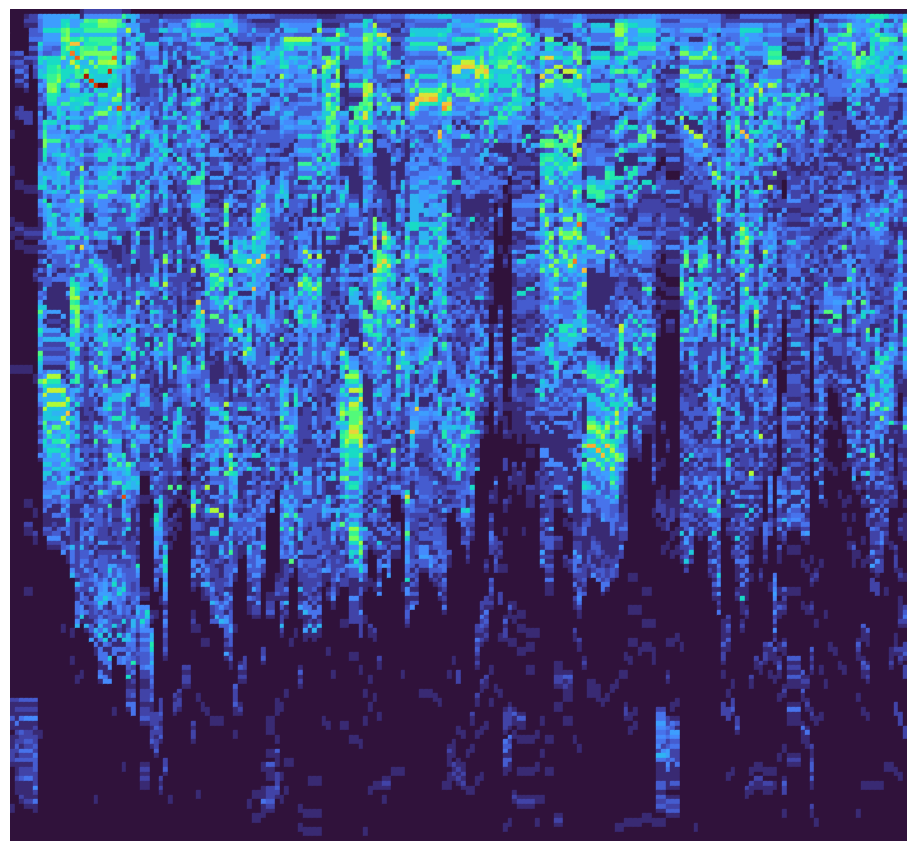

In [63]:
from ba_utils.orderings import get_priority_bfs_ordering_2, get_start_node
from ba_utils.network_rugs import draw_rug_from_graphs

# 1. DEFINE ACTIVE WINDOWS
interactions_per_window = df_2012.groupby("window").size()
active_windows = sorted(interactions_per_window[interactions_per_window > 50].index)
print(f"Windows before filter: {len(interactions_per_window)}")
print(f"Windows after filter: {len(active_windows)}")

# 2. REBUILD GRAPHS WITH ROLLING WINDOW (only active windows)
lookback = 8
graphs = {}

for i, w in enumerate(active_windows):  # ← active_windows instead of all_windows
    G = nx.Graph()
    G.add_nodes_from(nodes)
    
    past_windows = active_windows[max(0, i-lookback):i+1]  # ← active_windows here too
    df_past = df_2012[df_2012["window"].isin(past_windows)]
    
    edge_weights = (
        df_past.groupby(["u", "v"])
        .size()
        .reset_index(name="weight")
    )
    G.add_weighted_edges_from(
        edge_weights[["u", "v", "weight"]].itertuples(index=False)
    )
    graphs[w] = G

# 3. SANITY CHECK
mid = list(graphs.keys())[len(graphs)//2]
sample = graphs[mid]
print(f"Components: {len(list(nx.connected_components(sample)))}")
print(f"Isolated nodes: {len(list(nx.isolates(sample)))}")
print(f"Nodes with edges: {sample.number_of_nodes() - len(list(nx.isolates(sample)))}")

# 4. RUN PRIORITY BFS
"""    Select a single consistent start node, either:
      - 'highest' / 'lowest':   extreme on the first graph
      - 'highest_global' / 'lowest_global': extreme aggregated across all graphs
"""
start_nodes = get_start_node(graphs, metric='degree', mode='lowest_global')
prio_bfs_ordering = get_priority_bfs_ordering_2(graphs, start_nodes=start_nodes)

# 5. VISUALIZE
draw_rug_from_graphs(
    graphs_data=graphs,
    ordering=prio_bfs_ordering,
    color_encoding="degree",
    pixel_size=6
)

Comparing to **standard BFS** using the same data as above..

BFS Ordering:
num_artists 180


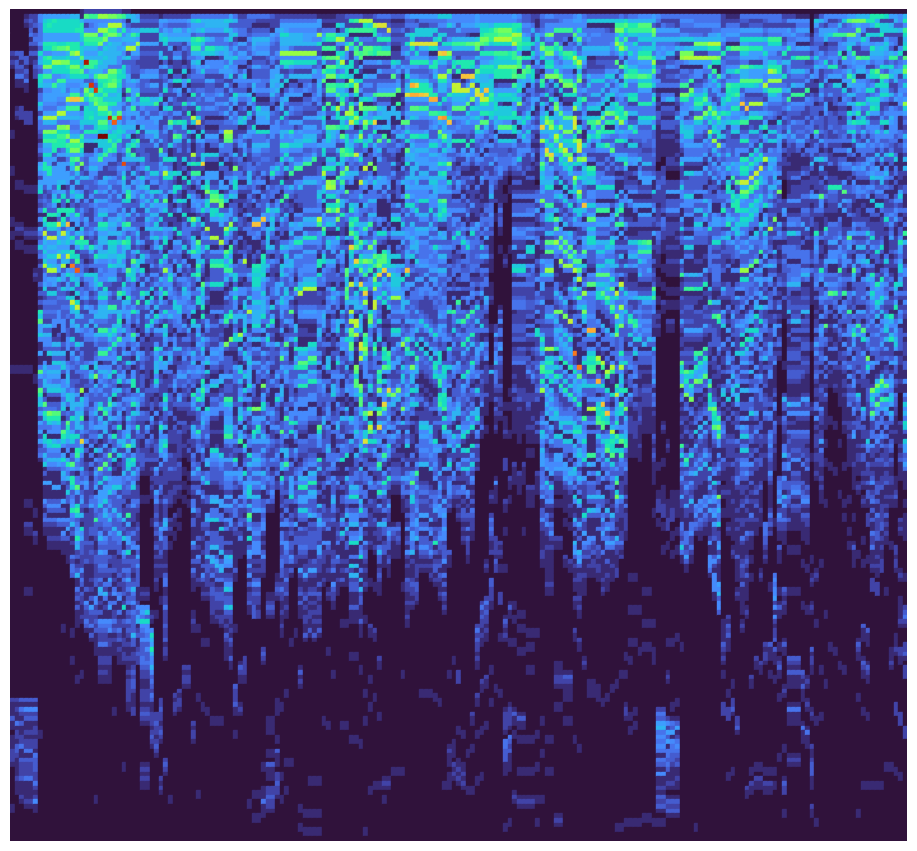

In [64]:
# sanity check, comparing our adapted prio bfs code to standard bfs
from ba_utils.orderings import get_BFS_ordering

"""    Select a single consistent start node, either:
      - 'highest' / 'lowest':   extreme on the first graph
      - 'highest_global' / 'lowest_global': extreme aggregated across all graphs
"""


start_nodes = get_start_node(graphs, metric='degree', mode='lowest_global')
bfs_ordering = get_BFS_ordering(graphs,start_nodes=start_nodes)

print("BFS Ordering:")
draw_rug_from_graphs(
    graphs_data=graphs,
    ordering=bfs_ordering,
    color_encoding="degree",
    pixel_size=6
)

They are both the same, so it is confirmation that the changes made to Priority BFS (*get_priority_bfs_ordering_2*) make the ordering behave like BFS, at least with this data

Using **Frederike's Priority BFS**  and playing with different start_node metrics (options:"degree", "closeness_centrality", "betweenness_centrality", "eigenvector_centrality") and modes (highest, lowest, highest_global, lowest_global)

#### start nodes: Metric = degree, mode = highest

Global stats: ((1, 410), (0, 29), (0, 10))
num_artists 4


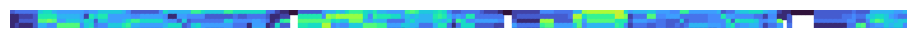

In [65]:
from ba_utils.orderings import get_priority_bfs_ordering, get_start_node
from ba_utils.network_rugs import draw_rug_from_graphs

"""    Select a single consistent start node, either:
      - 'highest' / 'lowest':   extreme on the first graph
      - 'highest_global' / 'lowest_global': extreme aggregated across all graphs
"""

# 4. RUN PRIORITY BFS
start_nodes = get_start_node(graphs, metric='degree', mode='highest')
prio_bfs_ordering = get_priority_bfs_ordering(graphs, start_nodes=start_nodes)

# 5. VISUALIZE
draw_rug_from_graphs(
    graphs_data=graphs,
    ordering=prio_bfs_ordering,
    color_encoding="degree",
    pixel_size=6
)

#### start nodes: Metric = degree, mode = highest_global

Global stats: ((1, 410), (0, 29), (0, 10))
num_artists 4


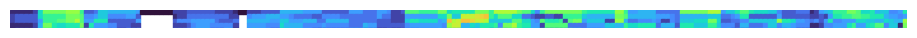

In [66]:
from ba_utils.orderings import get_priority_bfs_ordering, get_start_node
from ba_utils.network_rugs import draw_rug_from_graphs

"""    Select a single consistent start node, either:
      - 'highest' / 'lowest':   extreme on the first graph
      - 'highest_global' / 'lowest_global': extreme aggregated across all graphs
"""


# 4. RUN PRIORITY BFS
start_nodes = get_start_node(graphs, metric='degree', mode='highest_global')
prio_bfs_ordering = get_priority_bfs_ordering(graphs, start_nodes=start_nodes)

# 5. VISUALIZE
draw_rug_from_graphs(
    graphs_data=graphs,
    ordering=prio_bfs_ordering,
    color_encoding="degree",
    pixel_size=6
)

In [68]:
from ba_utils.orderings import get_priority_bfs_ordering, get_start_node
from ba_utils.network_rugs import draw_rug_from_graphs

"""    Select a single consistent start node, either:
      - 'highest' / 'lowest':   extreme on the first graph
      - 'highest_global' / 'lowest_global': extreme aggregated across all graphs
"""

# 4. RUN PRIORITY BFS
start_nodes = get_start_node(graphs, metric='degree', mode='lowest')
prio_bfs_ordering = get_priority_bfs_ordering(graphs, start_nodes=start_nodes)

# 5. VISUALIZE
draw_rug_from_graphs(
    graphs_data=graphs,
    ordering=prio_bfs_ordering,
    color_encoding="degree",
    pixel_size=6
)

Global stats: ((1, 410), (0, 29), (0, 10))
num_artists 1


Frederike found **betweenness_centrality** to be the best for prio bfs:

Global stats: ((1, 410), (0, 29), (0, 10))
num_artists 5


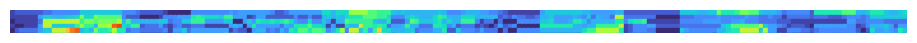

In [69]:
from ba_utils.orderings import get_priority_bfs_ordering, get_start_node
from ba_utils.network_rugs import draw_rug_from_graphs

# 4. RUN PRIORITY BFS
start_nodes = get_start_node(graphs, metric='betweenness_centrality', mode='highest')
prio_bfs_ordering = get_priority_bfs_ordering(graphs, start_nodes=start_nodes)

# 5. VISUALIZE
draw_rug_from_graphs(
    graphs_data=graphs,
    ordering=prio_bfs_ordering,
    color_encoding="degree",
    pixel_size=6
)

In [70]:
from ba_utils.orderings import get_priority_bfs_ordering, get_start_node
from ba_utils.network_rugs import draw_rug_from_graphs

# 4. RUN PRIORITY BFS
start_nodes = get_start_node(graphs, metric='betweenness_centrality', mode='highest_global')
prio_bfs_ordering = get_priority_bfs_ordering(graphs, start_nodes=start_nodes)

# 5. VISUALIZE
draw_rug_from_graphs(
    graphs_data=graphs,
    ordering=prio_bfs_ordering,
    color_encoding="degree",
    pixel_size=6
)

Global stats: ((1, 410), (0, 29), (0, 10))
num_artists 1


In [71]:
from ba_utils.orderings import get_priority_bfs_ordering, get_start_node
from ba_utils.network_rugs import draw_rug_from_graphs

# 4. RUN PRIORITY BFS
start_nodes = get_start_node(graphs, metric='betweenness_centrality', mode='lowest_global')
prio_bfs_ordering = get_priority_bfs_ordering(graphs, start_nodes=start_nodes)

# 5. VISUALIZE
draw_rug_from_graphs(
    graphs_data=graphs,
    ordering=prio_bfs_ordering,
    color_encoding="degree",
    pixel_size=6
)

Global stats: ((1, 410), (0, 29), (0, 10))
num_artists 1


In [72]:
standard_ordering = get_priority_bfs_ordering(graphs, start_nodes=start_nodes)
priority_ordering = get_priority_bfs_ordering_2(graphs, start_nodes=start_nodes)

# Compare a middle timestamp
t = list(graphs.keys())[len(graphs)//2]

std = standard_ordering[t]
pri = priority_ordering[t]

differences = sum(1 for a, b in zip(std, pri) if a != b)
print(f"Nodes in different positions: {differences} out of {len(std)}")

Global stats: ((1, 410), (0, 29), (0, 10))
Nodes in different positions: 0 out of 1


## testing new start_node approach, where the best starting node is chosen per timestamp not accross all data (so far the best node would not traverse more than 4 timestamps)

In [75]:
from ba_utils.orderings import get_start_node_local

# Run both
start_nodes_global = get_start_node(graphs, metric='betweenness_centrality', mode='highest_global')
start_nodes_local  = get_start_node_local(graphs, metric='betweenness_centrality', mode='highest')

# 1. Check how many unique start nodes each version produces
print(f"Unique nodes (global): {len(set(start_nodes_global.values()))}")  # will always be 1
print(f"Unique nodes (local):  {len(set(start_nodes_local.values()))}")   # should be > 1

# 2. Check a few timestamps side by side
for ts in list(graphs.keys())[:5]:
    print(f"ts={ts} | global: {start_nodes_global[ts]} | local: {start_nodes_local[ts]}")

# 3. Check that all local start nodes actually exist in their respective graphs
missing = [ts for ts, node in start_nodes_local.items() if node not in graphs[ts].nodes]
print(f"Timestamps where local start node is missing: {missing}")  # should be []

# 4. Check that local start nodes are never isolated
isolated = [ts for ts, node in start_nodes_local.items() if graphs[ts].degree(node) == 0]
print(f"Timestamps where local start node is isolated: {isolated}")  # ideally []

Unique nodes (global): 1
Unique nodes (local):  41
ts=1353303600 | global: 826 | local: 1672
ts=1353304800 | global: 826 | local: 1672
ts=1353306000 | global: 826 | local: 1672
ts=1353307200 | global: 826 | local: 1644
ts=1353308400 | global: 826 | local: 1644
Timestamps where local start node is missing: []
Timestamps where local start node is isolated: []


Global stats: ((1, 410), (0, 29), (0, 10))
num_artists 5


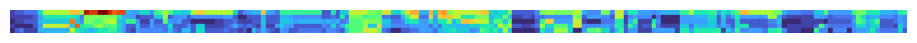

In [77]:
# testing the new start node function
# I underatand this new function is not ideal, because to my understanding, the whole concenpt is when choosing the right node, we can traverse the whol graph,
# but this isnt possible if most nodes disappear since they are no longer in contact after a few timesteps
from ba_utils.orderings import get_priority_bfs_ordering, get_start_node_local
from ba_utils.network_rugs import draw_rug_from_graphs

# 4. RUN PRIORITY BFS
start_nodes = get_start_node_local(graphs, metric='betweenness_centrality', mode='highest')
prio_bfs_ordering = get_priority_bfs_ordering(graphs, start_nodes=start_nodes)

# 5. VISUALIZE
draw_rug_from_graphs(
    graphs_data=graphs,
    ordering=prio_bfs_ordering,
    color_encoding="degree",
    pixel_size=6
)

<Axes: title={'center': 'snapshot structure over time'}, xlabel='window'>

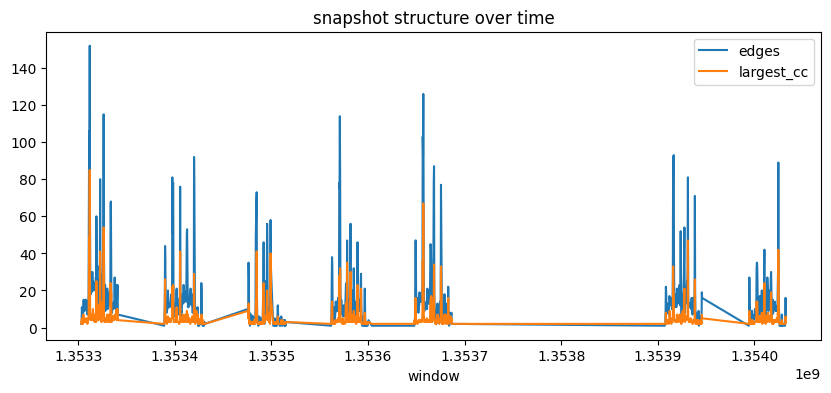

In [28]:
# number of edges per snapshot - Is there any interaction in this window?
edges_per_window = {
    w: G.number_of_edges() for w, G in graphs.items()
}

# connected components - Is the network fragmented into many isolated pieces?
components_per_window = {
    w: nx.number_connected_components(G) for w, G in graphs.items()
}

# largest connected component - Is there a group, not just pairs?
largest_cc = {}

for w, G in graphs.items():
    if G.number_of_edges() == 0:
        largest_cc[w] = 0
    else:
        largest_cc[w] = len(max(nx.connected_components(G), key=len))

# summarz for comparisons
summary_df = pd.DataFrame({
    "window": list(graphs.keys()),
    "edges": list(edges_per_window.values()),
    "largest_cc": list(largest_cc.values())
}).sort_values("window")

summary_df.plot(
    x="window",
    y=["edges", "largest_cc"],
    figsize=(10, 4),
    title="snapshot structure over time"
)



The graph helps us because with Priority-BFS and NetworkRugs we:

- do not care how many times two nodes met

- however we do care whether the network has dense local neighborhoods

**largest_cc** : How many students are connected together in the largest group, tells us if there is a group or just isolated pairs in each snapshot

### Including empty windows for comparison

In [29]:
graphs_with_empty_windows = {}

all_windows = np.arange(
    df_2012["window"].min(),
    df_2012["window"].max() + window,
    window
)

for w in all_windows:
    G = nx.Graph()
    G.add_nodes_from(nodes)

    df_w = df_2012[df_2012["window"] == w]

    if not df_w.empty:
        edges = df_w.drop_duplicates(subset=["u", "v"])
        G.add_edges_from(edges[["u", "v"]].itertuples(index=False))

    graphs_with_empty_windows[w] = G    

### Printing windows and nodes when applying Priority-BFS

In [33]:
# Get all timestamps in sorted order
timestamps = sorted(prio_bfs_ordering.keys())

# 1️⃣ First window (earliest timestamp)
first_ts = timestamps[0]
first_window_nodes = prio_bfs_ordering[first_ts]
print(f"Timestamp {first_ts}: nodes in priority BFS order:")
print(first_window_nodes)

# 2️⃣ First 20 windows
for ts in timestamps[:20]:
    window_nodes = prio_bfs_ordering[ts]
    print(f"Timestamp {ts}: {len(window_nodes)} nodes")
    print(window_nodes)

Timestamp 1353303300: nodes in priority BFS order:
[600]
Timestamp 1353303300: 1 nodes
[600]
Timestamp 1353303600: 1 nodes
[600]
Timestamp 1353303900: 1 nodes
[600]
Timestamp 1353304200: 1 nodes
[600]
Timestamp 1353304500: 1 nodes
[600]
Timestamp 1353304800: 1 nodes
[600]
Timestamp 1353305100: 1 nodes
[600]
Timestamp 1353305400: 1 nodes
[600]
Timestamp 1353305700: 1 nodes
[600]
Timestamp 1353306000: 1 nodes
[600]
Timestamp 1353306300: 1 nodes
[600]
Timestamp 1353306600: 1 nodes
[600]
Timestamp 1353306900: 1 nodes
[600]
Timestamp 1353307200: 3 nodes
[600, 609, 690]
Timestamp 1353307500: 3 nodes
[600, 609, 690]
Timestamp 1353307800: 1 nodes
[600]
Timestamp 1353308100: 3 nodes
[600, 609, 690]
Timestamp 1353308400: 5 nodes
[600, 609, 613, 658, 690]
Timestamp 1353308700: 4 nodes
[600, 609, 613, 690]
Timestamp 1353309000: 3 nodes
[600, 613, 658]


In [37]:
for ts, nodes in prio_bfs_ordering.items():
    print(f"{ts}: {len(nodes)} nodes -> {nodes[:10]}")  # first 10 nodes

1353303300: 1 nodes -> [600]
1353303600: 1 nodes -> [600]
1353303900: 1 nodes -> [600]
1353304200: 1 nodes -> [600]
1353304500: 1 nodes -> [600]
1353304800: 1 nodes -> [600]
1353305100: 1 nodes -> [600]
1353305400: 1 nodes -> [600]
1353305700: 1 nodes -> [600]
1353306000: 1 nodes -> [600]
1353306300: 1 nodes -> [600]
1353306600: 1 nodes -> [600]
1353306900: 1 nodes -> [600]
1353307200: 3 nodes -> [600, 609, 690]
1353307500: 3 nodes -> [600, 609, 690]
1353307800: 1 nodes -> [600]
1353308100: 3 nodes -> [600, 609, 690]
1353308400: 5 nodes -> [600, 609, 613, 658, 690]
1353308700: 4 nodes -> [600, 609, 613, 690]
1353309000: 3 nodes -> [600, 613, 658]
1353309300: 4 nodes -> [600, 613, 609, 658]
1353309600: 1 nodes -> [600]
1353309900: 3 nodes -> [600, 609, 690]
1353310200: 3 nodes -> [600, 609, 690]
1353310500: 3 nodes -> [600, 609, 690]
1353310800: 1 nodes -> [600]
1353311100: 1 nodes -> [600]
1353311400: 5 nodes -> [600, 866, 871, 854, 634]
1353311700: 5 nodes -> [600, 634, 866, 854, 871]

weird, seems as though there are many many timestamps where there is only 1 node (there should be at least one if each timestamp contains at least one interaction/edge)
To Do:
- investigate whether the graphs are being built correctly (why is there only a single node in many timestamps)
- this still doesnt fix the issue with traversing

Global stats: ((1, 1), (0, 15), (0, 7))
num_artists 3
Global stats: ((1, 1), (0, 15), (0, 7))
num_artists 3
Global stats: ((1, 1), (0, 15), (0, 7))
num_artists 3
Global stats: ((1, 1), (0, 15), (0, 7))
num_artists 3


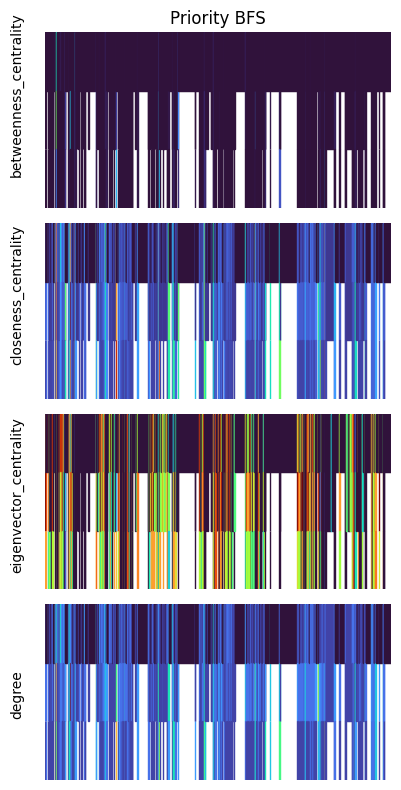

In [76]:
from ba_utils.orderings import get_start_node

# Choose strategy: 
# metric has options: degree, closeness_centrality
# 'highest_global' = highest average metric across all time
start_nodes = get_start_node(graphs, metric='degree', mode='highest_global')

orders = {
    "Priority BFS": "priority",
}

color_encodings = ['betweenness_centrality', 'closeness_centrality', 'eigenvector_centrality','degree']

# The rest of your code remains the same
fig = draw_networkrug_matrix_with_y_labels_with_frederike_wrapper(
    graphs=graphs,
    orders=orders,
    color_encodings=color_encodings,
    pixel_size=6,
    start_nodes=start_nodes
)

plt.show()

Frederike consistently initialized DFS, BFS and Priority BFS using the node with highest betweenness centrality accross among all time steps (p.24 thesis)


### Why Priority BFS might not be working


Priority BFS Ordering:
num_artists 180


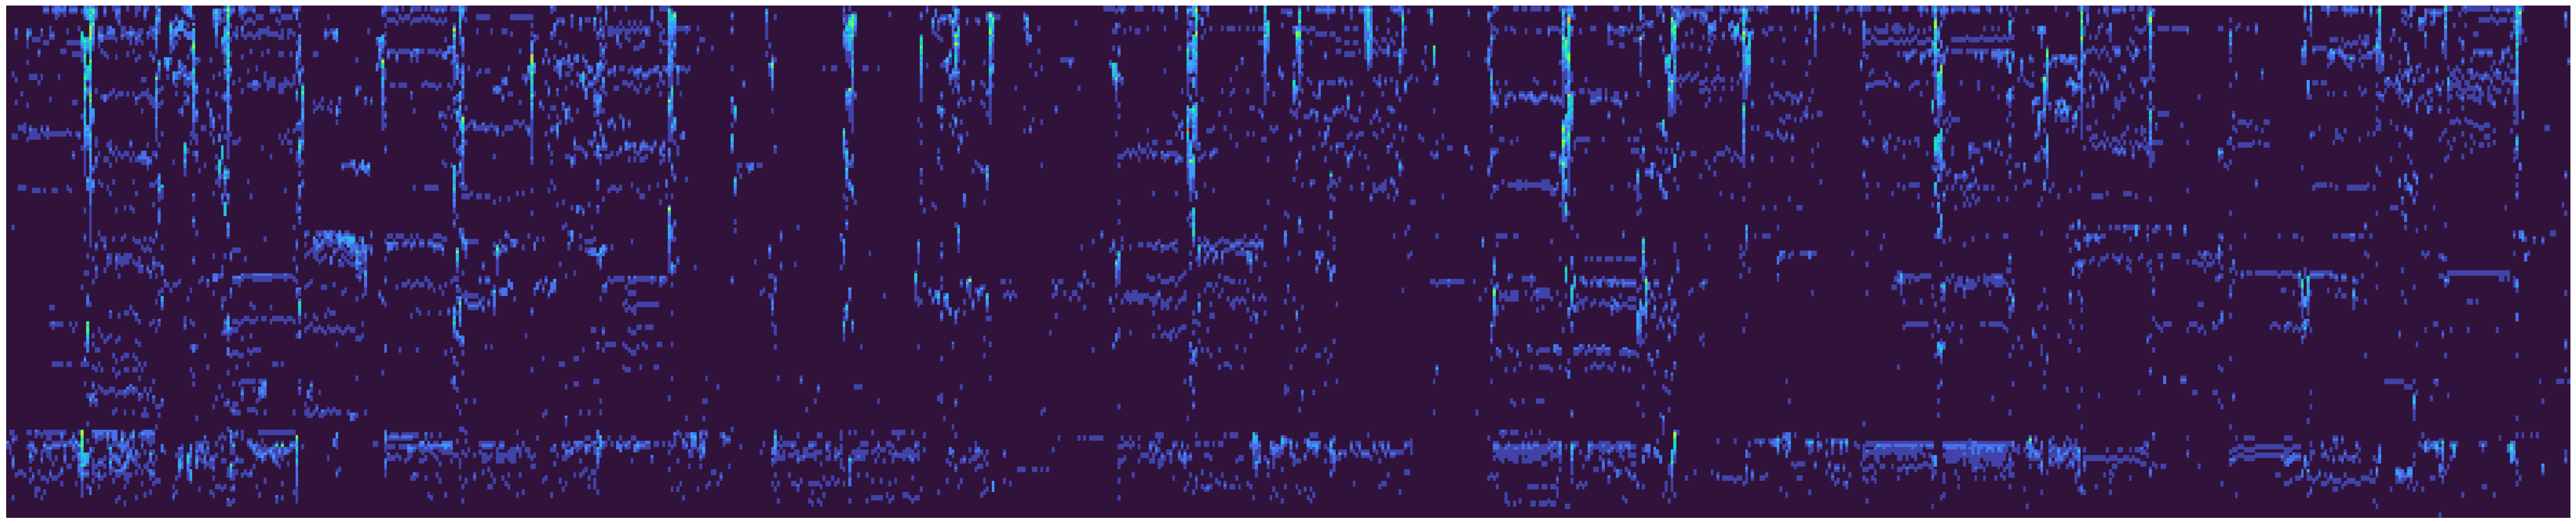

In [57]:
from ba_utils.orderings import get_priority_bfs_ordering_2
prio_bfs_ordering = get_priority_bfs_ordering_2(graphs)

print("Priority BFS Ordering:")
draw_rug_from_graphs(
    graphs_data=graphs,
    ordering=prio_bfs_ordering,
    color_encoding="degree",
    pixel_size=6
)



this is the exact same visualization obtained from bfs with degree color encoding...

In [59]:
# Assuming you have 'bfs_orders' and 'priority_orders'
ts = list(graphs.keys())[0]  # Check the first timestamp

if bfs_ordering[ts] == prio_bfs_ordering[ts]:
    print("The orderings are identical.")
else:
    # Find where they start to differ
    for i, (b, p) in enumerate(zip(bfs_ordering[ts], prio_bfs_ordering[ts])):
        if b != p:
            print(f"Difference starts at index {i}: BFS has {b}, Priority has {p}")
            break

The orderings are identical.


so... it didn't really work, because the make shift solution for the prio bfs turned it into a bfs

## Changes to the Priority BFS function (get_priority_bfs_ordering_3)

In [33]:
from ba_utils.orderings import get_priority_bfs_ordering_2, get_start_node
from ba_utils.network_rugs import draw_rug_from_graphs

In [34]:
G_simple = nx.Graph()
G_simple.add_nodes_from([1, 2, 3, 4])
G_simple.add_edges_from([(1,2), (2,3), (3,4)])

test_graphs = {0: G_simple}
result = get_priority_bfs_ordering_3(test_graphs, start_nodes={0: 1})
print(result)
# Should contain all 4 nodes: [1, 2, 3, 4] (order may vary slightly)
assert len(result[0]) == 4, "FAIL: not all nodes visited"
print("PASS: all nodes visited in connected graph")

Global stats: ((1, 1), (1, 2), (0, 1))
{0: [1, 2, 3, 4]}
PASS: all nodes visited in connected graph


Priority BFS Ordering:
num_artists 180


KeyboardInterrupt: 

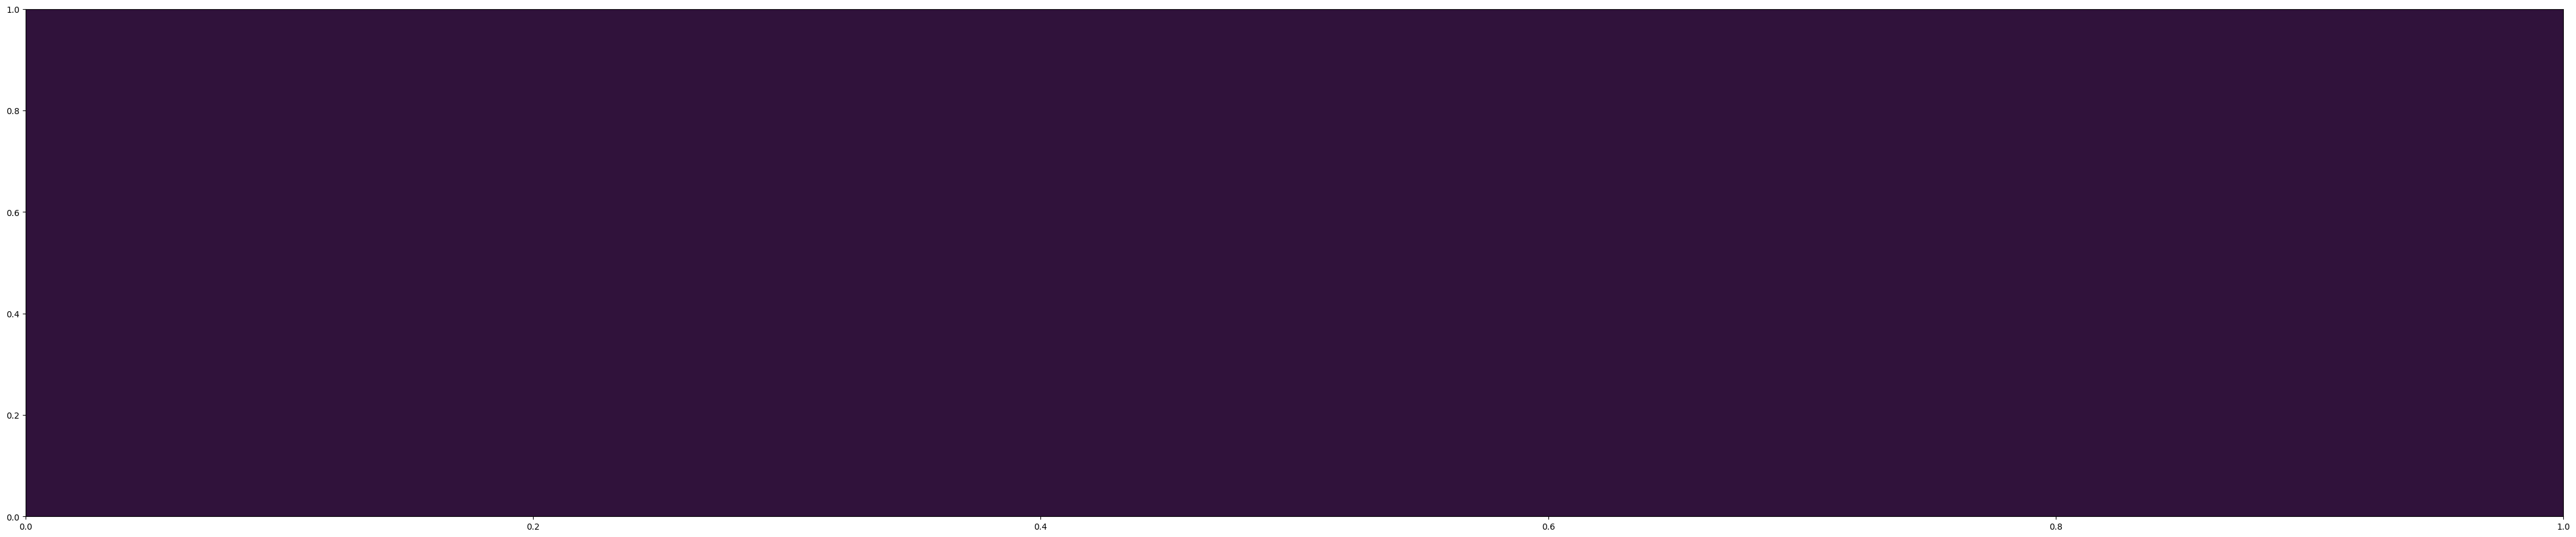

In [35]:
prio_bfs_ordering = get_priority_bfs_ordering_2(graphs)

"""    Select a single consistent start node, either:
      - 'highest' / 'lowest':   extreme on the first graph
      - 'highest_global' / 'lowest_global': extreme aggregated across all graphs
"""

start_nodes = get_start_node(graphs, metric='degree', mode='lowest_global')

print("Priority BFS Ordering:")
draw_rug_from_graphs(
    graphs_data=graphs,
    ordering=prio_bfs_ordering,
    color_encoding="degree",
    pixel_size=6
)

In [ ]:
# this is how frederike visualized the states of the graph - to see how the graph changes over time!
import networkx as nx
import random
import ba_utils.visualization as visualization
import ba_utils.orderings as orderings
import ba_utils.network_rugs as nrugs
import ba_utils.data_generator as dg

graphs, gt, changes = dg.generate_dynamic_graphs(
    num_nodes=12,
    num_steps= 15,
    initial_groups=1,
    change_rate=0,
    intra_community_strength=1,
    inter_community_strength=0.1,
    split_events={4: [(0, 5)]},
    seed=42
)
visualization.visualize_graphs(graphs)
#nrugs.draw_networkrug(graphs, color_encoding="id3", labels=True, pixel_size=20)

## Explored options
1. change priority bfs so it traverses all nodes (get_priority_bfs_ordering_2), but alorithm turned into a standard bfs
2. graphs have no edge weights, then the *calculate_priority* function is essentially computing the same score for every neighbor, making the priority queue behave just like a regular queue - so need to calculate weights in order for it to work

## Option 2: calculating weights by keeping every interaction and aggregating them for each window. Weight = how long the interaction lasts within the window